## Questions 
1. How well do different job titles pay?
2. How well do different skills pay for the role of Data Analyst?
## Methodology 
1. Cleaning the data by converting hourly rate to yearly rate wherever applicable.
2. Creating a column with avergae salary in PLN using exchange rate (1 USD= 4.198 PLN).
3. Evaluating median salary(in PLN) for top 6 data jobs in Poland.
4. Find median salary per skill for Data Analysts.
5. Visualisation

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import ast
import seaborn as sns
from datasets import load_dataset

In [188]:
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()
df_work=df.copy()

In [189]:
# Converting job_posted_date to datetime object 
df_work["job_posted_date"]=pd.to_datetime(df_work["job_posted_date"])

# Converting job_skills to list 
df_work["job_skills"]=df_work.job_skills.apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Creating a column with avergae salary in PLN 
-- We use the avergae exchange rate of USD to PLN in year 2023, i.e (1 USD= 4.198 PLN)

In [190]:
df_work["salary_year_avg_in_PLN"]=df_work["salary_year_avg"].apply(lambda x: x*4.198 if pd.notna(x) else x)
df_work=df_work[pd.notna(df_work["salary_year_avg_in_PLN"])==True]
df_work

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_in_PLN
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"[gdpr, excel]","{'analyst_tools': ['excel'], 'libraries': ['gd...",459681.000
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"[mongodb, mongodb, python, r, sql, mysql, mari...","{'analyst_tools': ['tableau'], 'cloud': ['orac...",587720.000
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}",503760.000
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr...",958075.956
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",373622.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"[go, python, r, sql, oracle, windows, alteryx,...","{'analyst_tools': ['alteryx', 'power bi', 'tab...",584428.768
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",NaN,NaN,629700.000
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"[python, azure, snowflake, spark]","{'cloud': ['azure', 'snowflake'], 'libraries':...",931431.250
785682,Data Scientist,Data Scientist für datengetriebene Entwicklung...,"Reutlingen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-04 06:16:08,False,False,Germany,year,157500.0,NaN,Bosch Group,"[python, hadoop, spark, airflow, kubernetes]","{'libraries': ['hadoop', 'spark', 'airflow'], ...",661185.000


## Poland 

In [191]:
#Filtering jobs in Poland 
df_Poland= df_work[df.job_country=="Poland"].reset_index()
df_Poland

/var/folders/wv/wbhpvhrj0td4yv7vwjbnnd340000gn/T/ipykernel_52004/2328165381.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_Poland= df_work[df.job_country=="Poland"].reset_index()


,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_in_PLN
0,1490,Data Analyst,HR Data Analyst,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-12-16 13:11:23,False,False,Poland,year,43200.0,NaN,Westinghouse Electric Company,"[gdpr, sap, powerpoint, excel]","{'analyst_tools': ['sap', 'powerpoint', 'excel...",181353.6
1,6567,Data Analyst,Data Analytics Assistant,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-04-25 13:25:00,True,False,Poland,year,56700.0,NaN,Publicis Groupe,"[r, python, spark, tidyverse, pandas, numpy]","{'libraries': ['spark', 'tidyverse', 'pandas',...",238026.6
2,11088,Data Engineer,Big Data Engineer,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-04-15 13:20:55,True,False,Poland,year,45000.0,NaN,Allegro,"[sql, java, kotlin, scala, groovy, gcp, bigque...","{'cloud': ['gcp', 'bigquery'], 'libraries': ['...",188910.0
3,12745,Data Analyst,Senior Clinical Data Manager I,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-29 13:14:00,False,False,Poland,year,72900.0,NaN,Allucent,"[word, excel, powerpoint]","{'analyst_tools': ['word', 'excel', 'powerpoin...",306034.2
4,12986,Data Engineer,Data Engineer,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-02-17 13:46:15,False,False,Poland,year,147500.0,NaN,Alter Solutions,NaN,NaN,619205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,774165,Data Analyst,Data Architect (BN),"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-01-20 02:02:50,False,False,Poland,year,165000.0,NaN,Alter Solutions,NaN,NaN,692670.0
196,774335,Software Engineer,Senior Linux Software Engineer – Robotics,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-17 01:25:07,False,False,Poland,year,89100.0,NaN,Alarm.com,"[python, c++, azure, linux, ubuntu, docker]","{'cloud': ['azure'], 'os': ['linux', 'ubuntu']...",374041.8
197,774339,Business Analyst,Regional Insight Analyst (CRM & Loyalty) for E...,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-03-16 01:24:09,False,False,Poland,year,80850.0,NaN,H&M Group,"[sql, sas, sas, tableau]","{'analyst_tools': ['sas', 'tableau'], 'program...",339408.3
198,776783,Cloud Engineer,[GPT] Cloud Security Engineer,"Kraków, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-07-20 05:17:06,True,False,Poland,year,56700.0,NaN,Software Mind,"[aws, azure, gcp]","{'cloud': ['aws', 'azure', 'gcp']}",238026.6


In [192]:
df_Poland.drop(columns="index", inplace=True)
df_Poland

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_in_PLN
0,Data Analyst,HR Data Analyst,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-12-16 13:11:23,False,False,Poland,year,43200.0,NaN,Westinghouse Electric Company,"[gdpr, sap, powerpoint, excel]","{'analyst_tools': ['sap', 'powerpoint', 'excel...",181353.6
1,Data Analyst,Data Analytics Assistant,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-04-25 13:25:00,True,False,Poland,year,56700.0,NaN,Publicis Groupe,"[r, python, spark, tidyverse, pandas, numpy]","{'libraries': ['spark', 'tidyverse', 'pandas',...",238026.6
2,Data Engineer,Big Data Engineer,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-04-15 13:20:55,True,False,Poland,year,45000.0,NaN,Allegro,"[sql, java, kotlin, scala, groovy, gcp, bigque...","{'cloud': ['gcp', 'bigquery'], 'libraries': ['...",188910.0
3,Data Analyst,Senior Clinical Data Manager I,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-29 13:14:00,False,False,Poland,year,72900.0,NaN,Allucent,"[word, excel, powerpoint]","{'analyst_tools': ['word', 'excel', 'powerpoin...",306034.2
4,Data Engineer,Data Engineer,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-02-17 13:46:15,False,False,Poland,year,147500.0,NaN,Alter Solutions,NaN,NaN,619205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Data Analyst,Data Architect (BN),"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-01-20 02:02:50,False,False,Poland,year,165000.0,NaN,Alter Solutions,NaN,NaN,692670.0
196,Software Engineer,Senior Linux Software Engineer – Robotics,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-17 01:25:07,False,False,Poland,year,89100.0,NaN,Alarm.com,"[python, c++, azure, linux, ubuntu, docker]","{'cloud': ['azure'], 'os': ['linux', 'ubuntu']...",374041.8
197,Business Analyst,Regional Insight Analyst (CRM & Loyalty) for E...,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-03-16 01:24:09,False,False,Poland,year,80850.0,NaN,H&M Group,"[sql, sas, sas, tableau]","{'analyst_tools': ['sas', 'tableau'], 'program...",339408.3
198,Cloud Engineer,[GPT] Cloud Security Engineer,"Kraków, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-07-20 05:17:06,True,False,Poland,year,56700.0,NaN,Software Mind,"[aws, azure, gcp]","{'cloud': ['aws', 'azure', 'gcp']}",238026.6


In [193]:
df_Poland.job_title_short.value_counts()

job_title_short
Data Engineer                46
Data Analyst                 43
Data Scientist               29
Machine Learning Engineer    23
Software Engineer            15
Senior Data Scientist        12
Senior Data Engineer          9
Senior Data Analyst           9
Business Analyst              8
Cloud Engineer                6
Name: count, dtype: int64

In [194]:
top_titles=df_Poland.job_title_short.value_counts().index.to_list()
top_titles=top_titles[:3]
#+top_titles[5:8]
top_titles

['Data Engineer', 'Data Analyst', 'Data Scientist']

In [195]:
df_titles=df_Poland[df_Poland["job_title_short"].isin(top_titles)]
df_titles

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_in_PLN
0,Data Analyst,HR Data Analyst,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-12-16 13:11:23,False,False,Poland,year,43200.0,NaN,Westinghouse Electric Company,"[gdpr, sap, powerpoint, excel]","{'analyst_tools': ['sap', 'powerpoint', 'excel...",181353.6
1,Data Analyst,Data Analytics Assistant,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-04-25 13:25:00,True,False,Poland,year,56700.0,NaN,Publicis Groupe,"[r, python, spark, tidyverse, pandas, numpy]","{'libraries': ['spark', 'tidyverse', 'pandas',...",238026.6
2,Data Engineer,Big Data Engineer,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-04-15 13:20:55,True,False,Poland,year,45000.0,NaN,Allegro,"[sql, java, kotlin, scala, groovy, gcp, bigque...","{'cloud': ['gcp', 'bigquery'], 'libraries': ['...",188910.0
3,Data Analyst,Senior Clinical Data Manager I,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-29 13:14:00,False,False,Poland,year,72900.0,NaN,Allucent,"[word, excel, powerpoint]","{'analyst_tools': ['word', 'excel', 'powerpoin...",306034.2
4,Data Engineer,Data Engineer,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-02-17 13:46:15,False,False,Poland,year,147500.0,NaN,Alter Solutions,NaN,NaN,619205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,Data Analyst,Data Analyst (Pricing),Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-06-27 20:47:07,False,False,Poland,year,57500.0,NaN,Allegro,"[sql, gcp]","{'cloud': ['gcp'], 'programming': ['sql']}",241385.0
190,Data Scientist,Analytics Engineer,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-12-17 01:11:25,True,False,Poland,year,158500.0,NaN,Palta,"[python, sql, snowflake, airflow, looker, tabl...","{'analyst_tools': ['looker', 'tableau', 'power...",665383.0
192,Data Analyst,Cloud Data Administrator (Power BI),"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-12-22 01:11:00,True,False,Poland,year,72000.0,NaN,PUMA,"[sql, azure, power bi, dax]","{'analyst_tools': ['power bi', 'dax'], 'cloud'...",302256.0
195,Data Analyst,Data Architect (BN),"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-01-20 02:02:50,False,False,Poland,year,165000.0,NaN,Alter Solutions,NaN,NaN,692670.0


In [196]:
job_order=df_titles.groupby("job_title_short")["salary_year_avg_in_PLN"].median().round(2).sort_values(ascending=False).index
job_order

Index(['Data Engineer', 'Data Scientist', 'Data Analyst'], dtype='str', name='job_title_short')

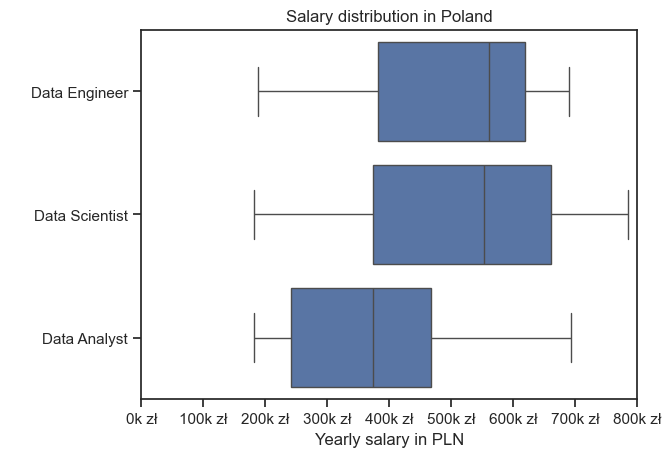

In [197]:
sns.set_theme(style="ticks")
sns.boxplot(df_titles, x="salary_year_avg_in_PLN", y="job_title_short", order=job_order)
plt.title("Salary distribution in Poland")
plt.ylabel(" ")
plt.xlabel("Yearly salary in PLN")
plt.xlim(0, 800000)
ax=plt.gca()
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)} tys."))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)}k zł"))
plt.show()

# Data Analyst 

In [198]:
#Filtering Data Analyst jobs in Poland
df_DA_PL=df_Poland[df_Poland.job_title_short=="Data Analyst"]
df_DA_PL

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_in_PLN
0,Data Analyst,HR Data Analyst,Poland,via Ai-Jobs.net,Full-time,False,Poland,2023-12-16 13:11:23,False,False,Poland,year,43200.0,NaN,Westinghouse Electric Company,"[gdpr, sap, powerpoint, excel]","{'analyst_tools': ['sap', 'powerpoint', 'excel...",181353.600
1,Data Analyst,Data Analytics Assistant,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-04-25 13:25:00,True,False,Poland,year,56700.0,NaN,Publicis Groupe,"[r, python, spark, tidyverse, pandas, numpy]","{'libraries': ['spark', 'tidyverse', 'pandas',...",238026.600
3,Data Analyst,Senior Clinical Data Manager I,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-29 13:14:00,False,False,Poland,year,72900.0,NaN,Allucent,"[word, excel, powerpoint]","{'analyst_tools': ['word', 'excel', 'powerpoin...",306034.200
6,Data Analyst,Marketing Data Analyst [BGSW],"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-07-25 13:26:07,True,False,Poland,year,111175.0,NaN,Bosch Group,"[spark, excel]","{'analyst_tools': ['excel'], 'libraries': ['sp...",466712.650
7,Data Analyst,Customer Data Operations Analyst,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-08-10 13:59:18,False,False,Poland,year,89100.0,NaN,Biogen,NaN,NaN,374041.800
13,Data Analyst,Data Analyst with Python,"Kraków, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-03-15 06:24:09,False,False,Poland,year,98500.0,NaN,OANDA,"[python, nosql, sql, c++, rust, numpy, pandas,...","{'libraries': ['numpy', 'pandas', 'matplotlib'...",413503.000
18,Data Analyst,Data Analyst/Custom Insights,"Kraków, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-01-11 00:35:05,False,False,Poland,year,45000.0,NaN,Verisk,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",188910.000
26,Data Analyst,Data Analyst,"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-04-13 08:26:45,True,False,Poland,year,102500.0,NaN,capital.com,"[airflow, tableau, power bi, git]","{'analyst_tools': ['tableau', 'power bi'], 'li...",430295.000
28,Data Analyst,Data Analyst (BN),"Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-05-01 08:20:57,False,False,Poland,year,111175.0,NaN,Alter Solutions,"[sas, sas, sql, gdpr, jira]","{'analyst_tools': ['sas'], 'async': ['jira'], ...",466712.650
29,Data Analyst,"Data Analytics & Reporting, Support Analyst","Warsaw, Poland",via Ai-Jobs.net,Full-time,False,Poland,2023-07-06 08:22:52,False,False,Poland,year,89100.0,NaN,Biogen,"[oracle, tableau, excel, outlook, sharepoint]","{'analyst_tools': ['tableau', 'excel', 'outloo...",374041.800


In [199]:
#Exploding the job skills
df_DA_PL=df_DA_PL.explode("job_skills")

In [200]:
df_DA_PL[["salary_year_avg_in_PLN", "job_skills"]].head()

,salary_year_avg_in_PLN,job_skills
0,181353.6,gdpr
0,181353.6,sap
0,181353.6,powerpoint
0,181353.6,excel
1,238026.6,r


In [201]:
df_DA_top_pay=df_DA_PL.groupby(["job_skills"])["salary_year_avg_in_PLN"].agg(["count", "median"]).sort_values(by="median", ascending=False).head(10)
df_DA_top_pay

,count,median
job_skills,,
aws,1,692670.00
mongo,1,692670.00
linux,1,692670.00
hadoop,2,561482.50
nosql,2,553086.50
looker,6,466712.65
jira,1,466712.65
spark,8,466712.65
airflow,5,466712.65


In [202]:
df_DA_top_count=df_DA_PL.groupby(["job_skills"])["salary_year_avg_in_PLN"].agg(["count", "median"]).sort_values(by="count", ascending=False).head(10)
df_DA_top_count.sort_values(by="median", ascending=False, inplace=True)
df_DA_top_count

,count,median
job_skills,,
tableau,13,466712.650
spark,8,466712.650
looker,6,466712.650
windows,5,466712.650
airflow,5,466712.650
gcp,10,448503.825
sql,26,430295.000
python,15,430295.000
power bi,8,345705.300


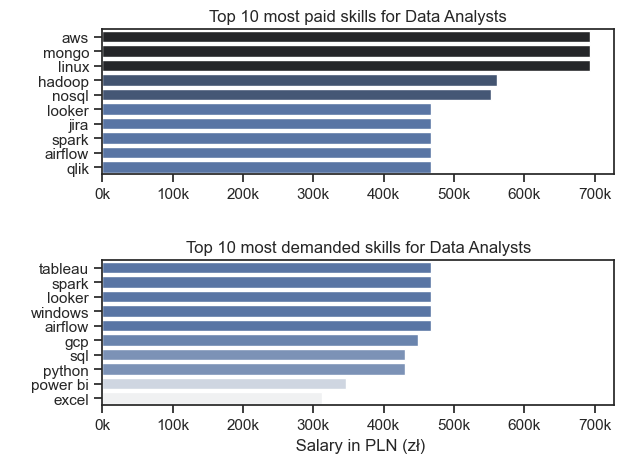

In [203]:
fig, ax=plt.subplots(2,1)
sns.set_theme(style="ticks")
sns.barplot(data=df_DA_top_pay,y=df_DA_top_pay.index, x="median", ax=ax[0], hue="median", palette="dark:b_r") 
ax[0].set_title("Top 10 most paid skills for Data Analysts")
ax[0].set_xlabel(" ")
ax[0].set_ylabel(" ")
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
sns.barplot(data=df_DA_top_count,y=df_DA_top_count.index, x="median", ax=ax[1], hue="median", palette="light:b") 
ax[1].set_title("Top 10 most demanded skills for Data Analysts")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylabel(" ")
ax[1].set_xlabel(" Salary in PLN (zł)")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
ax[1].legend().remove()
fig.tight_layout()
plt.show()